In [ ]:
import sys, os
sys.path.append(os.path.abspath(".."))

from src.utils import get_summary_stats

In [3]:
#Going to Install useful libraries

!pip install pandas 
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 20.2 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pandas]2m2/3 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 30.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


In [1]:
#Step 1

import numpy as np
import time

arr = np.arange(1_000_000)

start = time.time()
squared = arr ** 2
end = time.time()
print("Vectorized time:", end - start)

start = time.time()
squared_loop = [x**2 for x in arr]
end = time.time()
print("Loop time:", end - start)

Vectorized time: 0.0012998580932617188
Loop time: 0.040238142013549805


In [5]:
#Step 2

import pandas as pd

# Load the dataset
df = pd.read_csv("../data/starter_data.csv")

# Inspect structure
print("Dataset info:")
display(df.info())

# Show first rows
print("\nFirst 5 rows:")
display(df.head())

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  10 non-null     object
 1   value     10 non-null     int64 
 2   date      10 non-null     object
dtypes: int64(1), object(2)
memory usage: 372.0+ bytes


None


First 5 rows:


,category,value,date
0,A,10,2025-08-01
1,B,15,2025-08-02
2,A,12,2025-08-03
3,B,18,2025-08-04
4,C,25,2025-08-05


In [6]:
#This is for step 3

# Summary statistics for numeric columns
print("Summary statistics:")
display(df.describe())

# Groupby aggregation: average value per category
print("\nGroupby: mean value by category")
display(df.groupby("category")["value"].mean())

# You can also try sum, count, etc.
print("\nGroupby: sum of values by category")
display(df.groupby("category")["value"].sum())

Summary statistics:


,value
count,10.000000
mean,17.600000
std,7.381659
min,10.000000
25%,12.250000
50%,14.500000
75%,23.250000
max,30.000000



Groupby: mean value by category


category
A    11.500000
B    15.666667
C    27.666667
Name: value, dtype: float64


Groupby: sum of values by category


category
A    46
B    47
C    83
Name: value, dtype: int64

In [7]:
import os

# Ensure processed folder exists
os.makedirs("../data/processed", exist_ok=True)

# 1) Summary stats (describe)
summary = df.describe()
summary_path = "../data/processed/summary.csv"
summary.to_csv(summary_path, index=True)
print(f"Saved describe() → {summary_path}")

# 2) Groupby aggregations
group_mean = df.groupby("category")["value"].mean().reset_index(name="mean_value")
group_sum  = df.groupby("category")["value"].sum().reset_index(name="sum_value")

group_path = "../data/processed/groupby_stats.csv"
pd.merge(group_mean, group_sum, on="category").to_csv(group_path, index=False)
print(f"Saved groupby stats → {group_path}")

# (Optional) Also save JSON 
summary.to_json("../data/processed/summary.json", orient="table")
print("Also saved summary.json")

Saved describe() → ../data/processed/summary.csv
Saved groupby stats → ../data/processed/groupby_stats.csv
Also saved summary.json


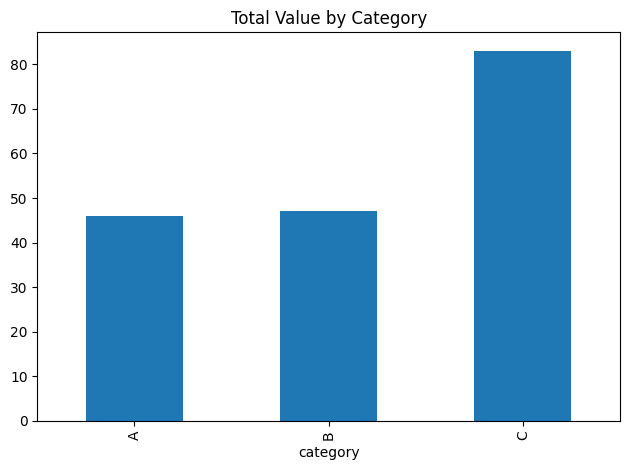

Saved plot → ../data/processed/total_by_category.png


In [8]:
import matplotlib.pyplot as plt

# Simple bar chart of sums by category
ax = df.groupby("category")["value"].sum().plot(kind="bar", title="Total Value by Category")
plt.tight_layout()
plot_path = "../data/processed/total_by_category.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Saved plot → {plot_path}")